In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import warnings 
warnings.filterwarnings('ignore') 

#
# 4.1 Loading Required Datasets
#

In [2]:

# load scaled matrices and target arrays
X_train = pd.read_csv('../data/X_train_scaled.csv', index_col=0)
X_test = pd.read_csv('../data/X_test_scaled.csv', index_col=0)

# use squeeze to convert single column dataframe into a pandas series for sklearn
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (1984, 22)
Testing features shape: (497, 22)


#
# 4.2 - ML MODELS PERFORMACE (ROC - AUC GRAPH)
#

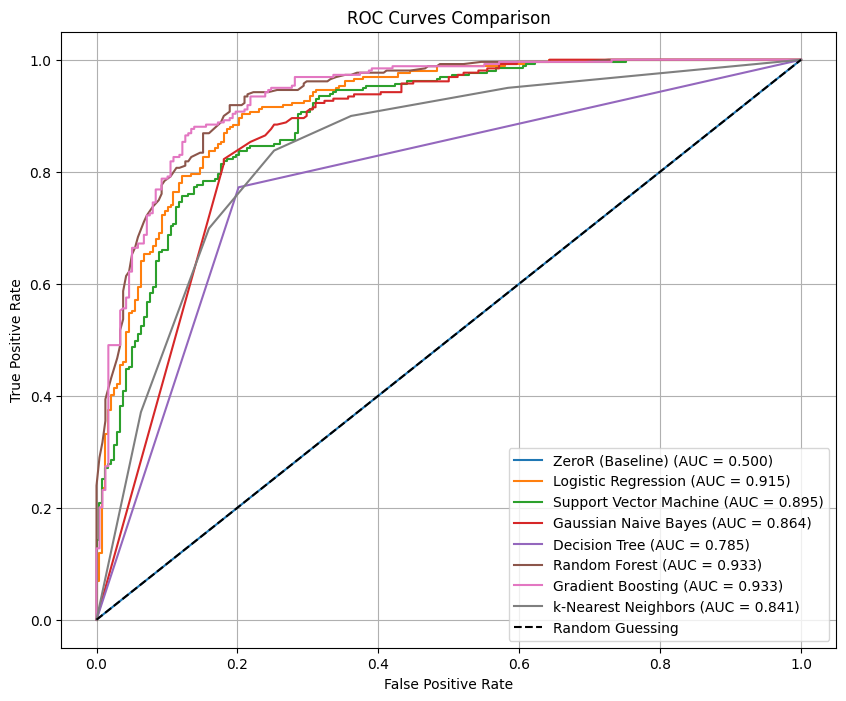

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ZeroR (Baseline),0.521127,0.521127,1.000000,0.685185,0.500000
1,Logistic Regression,0.839034,0.850980,0.837838,0.844358,0.915399
2,Support Vector Machine,0.798793,0.780919,0.853282,0.815498,0.894552
3,Gaussian Naive Bayes,0.736419,0.670213,0.972973,0.793701,0.863526
4,Decision Tree,0.784708,0.806452,0.772201,0.788955,0.785260
5,Random Forest,0.867203,0.840989,0.918919,0.878229,0.932870
6,Gradient Boosting,0.853119,0.825175,0.911197,0.866055,0.933057
7,k-Nearest Neighbors,0.794769,0.783394,0.837838,0.809701,0.840734


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# define the 8 models
models = {
    "ZeroR (Baseline)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier()
}

# list to store metrics dictionary for each model
results_list = []

# setup plotting for roc curves
plt.figure(figsize=(10, 8))

# loop through each model for training and evaluation
for name, model in models.items():
    # fit model
    model.fit(X_train, y_train)
    
    # generate predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    # store metrics
    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })
    
    # calculate roc curve coordinates
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# final roc curve formatting
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("../images-recordings/figures/auc_curve_all_models.png")
plt.show()

# convert results list to summary dataframe
performance_df = pd.DataFrame(results_list)
display(performance_df)


#
# 4.3 - ML Models Confusion Matrix 
#

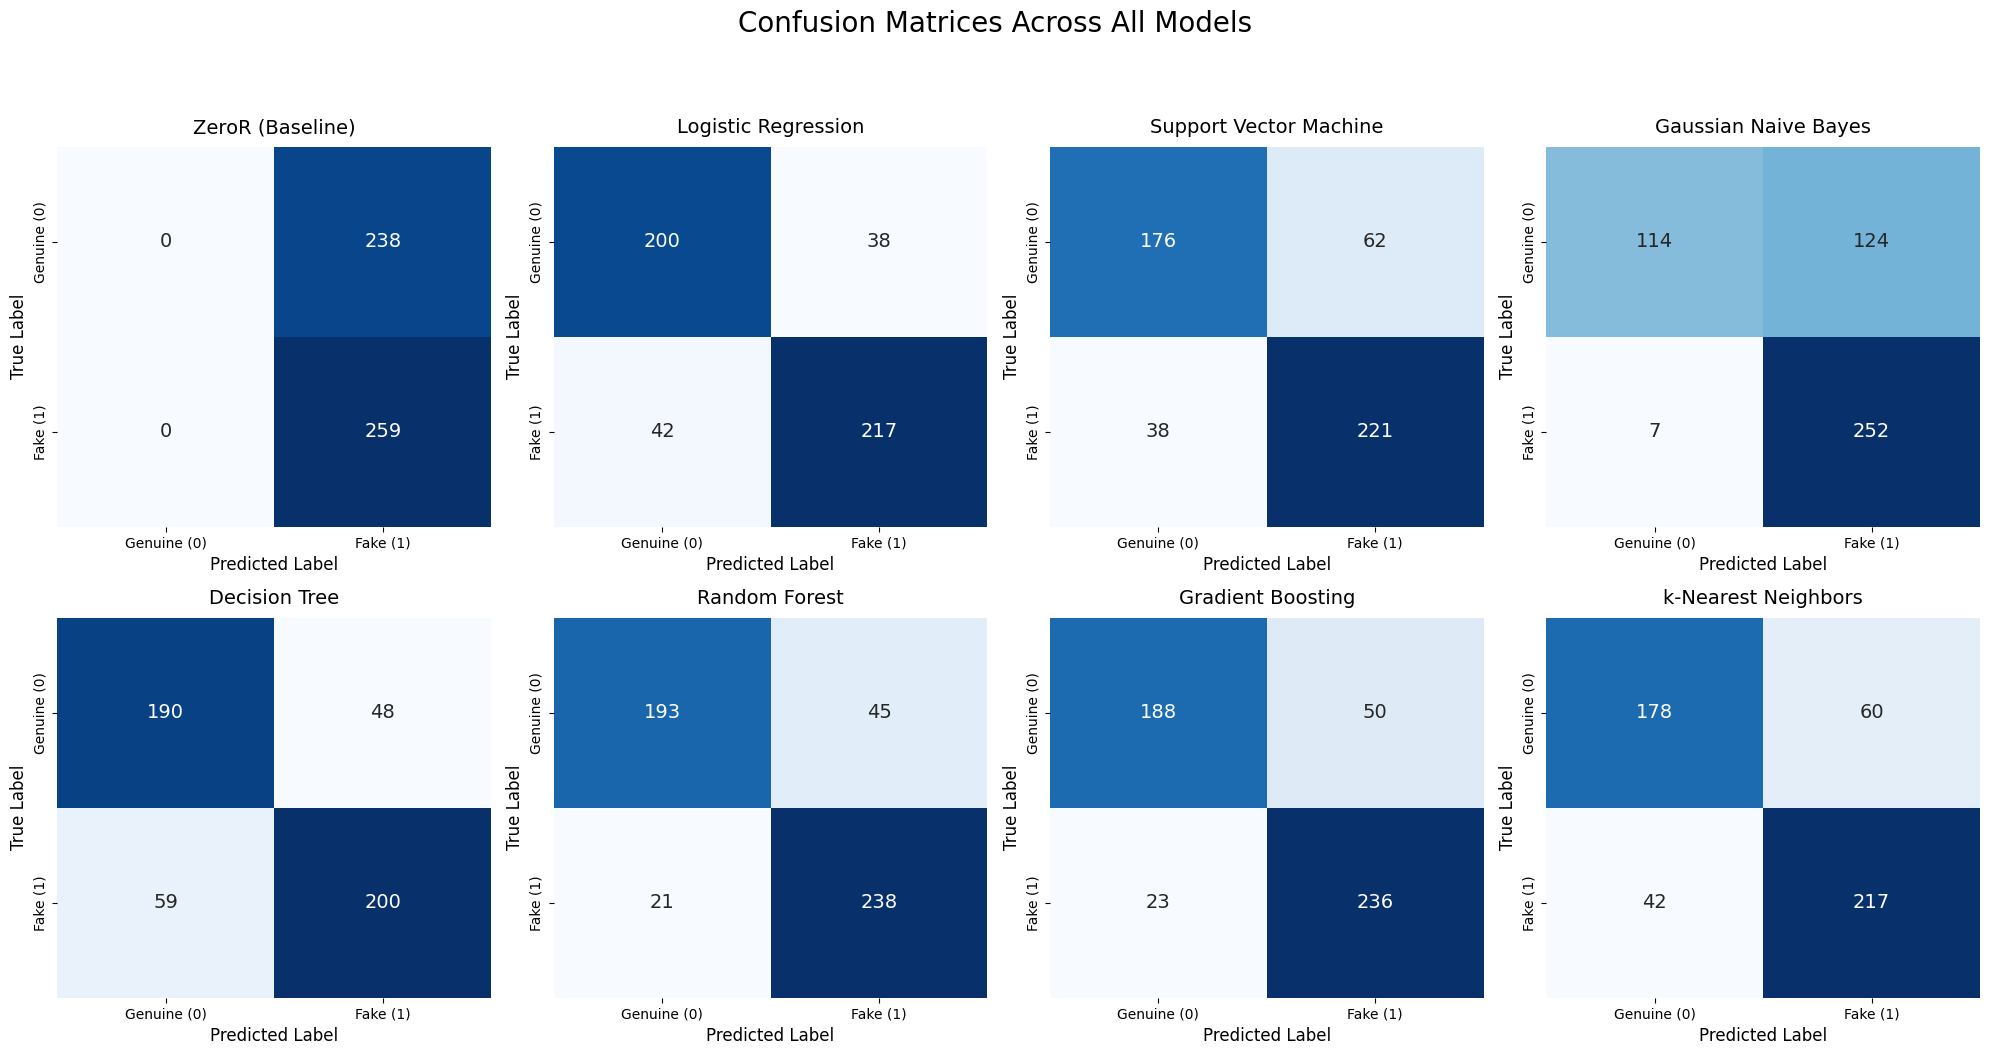

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a 2x4 grid for the 8 confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Loop through the already trained models to generate and plot matrices
for i, (name, model) in enumerate(models.items()):
    # Generate predictions using the existing models
    y_pred = model.predict(X_test)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    #  the matrix using seaborn heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={"size": 14}) # Increase font size for readability
    
    axes[i].set_title(f'{name}', fontsize=14, pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)
    
    # tick labels assuming 0 = Genuine, 1 = Fake
    axes[i].set_xticklabels(['Genuine (0)', 'Fake (1)'])
    axes[i].set_yticklabels(['Genuine (0)', 'Fake (1)'])

fig.suptitle('Confusion Matrices Across All Models', fontsize=20, y=1.05)

plt.tight_layout()

plt.savefig("../images-recordings/figures/confusion_matrices_all_models.png", bbox_inches='tight')

plt.show()

#
# 4.4 -  Saving Best Model For user input data for web application
# 

In [5]:
import joblib
from sklearn.ensemble import GradientBoostingClassifier

winning_model = GradientBoostingClassifier(random_state=42)

# 2. Train it on our scaled data
winning_model.fit(X_train, y_train)

# 3. Export the trained model as a joblib/pickle file
# We will save this to your root directory based on your VS Code structure
joblib.dump(winning_model, '../models/final_gradient_boost_model.pkl')



['../models/final_gradient_boost_model.pkl']